In [1]:
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
 
WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"
 
 
# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------
 
def fetch_sweep_runs(sweep_name: str) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs
 
 
def compute_epoch_df(
    sweep_name: str,
    loss_metric: str,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
) -> pd.DataFrame:
    """
    Fetches all runs and returns a raw epoch-level DataFrame.
    One row per (x_val, run_val, seed_val, epoch).
 
    The optimality gap is computed as:
        opt_gap = loss[epoch] - floor(x_val, run_val)
    where floor = min loss across all seeds and epochs for that (x_val, run_val).
 
    Parameters
    ----------
    sweep_name    : W&B sweep ID
    loss_metric   : metric used to compute the optimality gap (also stored as a column)
    value_metrics : metrics to fetch and store as columns
    x_key         : config key for the grouping dimension (e.g. "stores")
    run_key       : config key identifying a unique policy (e.g. "run_idx")
    seed_key      : config key identifying the seed (e.g. "a_seed")
 
    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, {run_key}, {seed_key}, epoch, {loss_metric}, opt_gap, *value_metrics
    Metrics that are missing for a given epoch are NaN.
    """
    runs = fetch_sweep_runs(sweep_name)
    all_keys = [loss_metric] + value_metrics
    identifier_keys = (x_key, run_key, seed_key)
 
    # --- Step 1: fetch histories ---
    run_data = {}
    for run in runs:
        cfg = run.config
        try:
            key = tuple(cfg[k] for k in identifier_keys)
        except KeyError as e:
            print(f"Skipping run {run.id}: missing config key {e}")
            continue
 
        history = run.history(keys=all_keys, pandas=True)
        if history.empty:
            continue
 
        available = [c for c in all_keys if c in history.columns]
        sub = history[available].dropna(subset=[loss_metric]).reset_index(drop=True)
        if sub.empty:
            continue
 
        run_data[key] = sub
 
    if not run_data:
        raise ValueError("No valid run data found.")
 
    print(f"Valid runs: {len(run_data)}")
 
    # --- Step 2: compute floor per (x_val, run_val) ---
    floor: dict[tuple, float] = defaultdict(lambda: np.inf)
    for (x_val, run_val, seed_val), sub in run_data.items():
        policy_key = (x_val, run_val)
        floor[policy_key] = min(floor[policy_key], float(sub[loss_metric].min()))
 
    # --- Step 3: build epoch-level rows ---
    records = []
    for (x_val, run_val, seed_val), sub in run_data.items():
        best    = floor[(x_val, run_val)]
        opt_gap = sub[loss_metric].values - best
 
        chunk = sub.copy()
        chunk.insert(0, x_key,    x_val)
        chunk.insert(1, run_key,  run_val)
        chunk.insert(2, seed_key, seed_val)
        chunk.insert(3, "epoch",  np.arange(len(chunk)))
        chunk["opt_gap"] = opt_gap
        records.append(chunk)
 
    result = pd.concat(records, ignore_index=True)
 
    # Reorder: identifiers first, then opt_gap, then metrics
    id_cols     = [x_key, run_key, seed_key, "epoch", loss_metric, "opt_gap"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    return result[id_cols + metric_cols]
 
 
# ---------------------------------------------------------------------------
# Derived metrics (epoch-level)
# ---------------------------------------------------------------------------
 
def add_derived_metrics(
    epoch_df: pd.DataFrame,
    derived: dict[str, callable],
) -> pd.DataFrame:
    """
    Adds derived metric columns to the epoch-level DataFrame.
    Each callable receives the DataFrame and returns a Series.
 
    Parameters
    ----------
    epoch_df : output of compute_epoch_df
    derived  : dict mapping new column name -> callable(df) -> pd.Series
 
    Example
    -------
    derived = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df["train/grad_norm/continuous/pathwise/true"]
            / df["train/grad_norm/continuous/cross_ppo/true"]
        ),
    }
 
    Returns
    -------
    epoch_df with new columns appended (original df is not mutated).
    """
    result = epoch_df.copy()
    for name, fn in derived.items():
        try:
            result[name] = fn(result)
        except Exception as e:
            print(f"Could not compute derived metric '{name}': {e}")
    return result
 
 
# ---------------------------------------------------------------------------
# Bucketing + aggregation
# ---------------------------------------------------------------------------
 
def compute_bucketed_metrics(
    epoch_df: pd.DataFrame,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
    bucket_metric: str = "opt_gap",
    bucket_width: float = 5.0,
) -> pd.DataFrame:
    """
    Aggregates epoch-level data into buckets using two-stage averaging:
      Stage 1: mean per (run_key, seed_key, bucket)  — equal epoch weight per run
      Stage 2: simple average across (run_key, seed_key) — equal run weight
 
    Parameters
    ----------
    epoch_df      : output of compute_epoch_df (optionally with derived columns added)
    value_metrics : columns to aggregate
    x_key         : grouping dimension column (e.g. "stores")
    run_key       : run identity column (e.g. "run_idx")
    seed_key      : seed identity column (e.g. "a_seed")
    bucket_metric : column to bucketize on (e.g. "opt_gap" or any value metric)
    bucket_width  : width of each bucket
 
    Returns
    -------
    Wide-format pd.DataFrame with columns:
        {x_key}, bucket_left, bucket_right, {metric_1}, {metric_2}, ...
    One row per (x_val, bucket). Missing metric/bucket combos are NaN.
    """
    df = epoch_df.copy()
    df["bucket_left"] = (df[bucket_metric] // bucket_width) * bucket_width
 
    agg_records = []
    for x_val in df[x_key].unique():
        sub_x = df[df[x_key] == x_val]
 
        bucket_agg: dict[float, dict] = {}
        for metric in value_metrics:
            if metric not in sub_x.columns:
                continue
 
            rows = sub_x[[run_key, seed_key, "bucket_left", metric]].dropna(subset=[metric])
            if rows.empty:
                continue
 
            # Stage 1: mean per (run, seed, bucket)
            per_run = (
                rows.groupby([run_key, seed_key, "bucket_left"])[metric]
                .mean()
                .reset_index()
                .rename(columns={metric: "run_mean"})
            )
 
            # Stage 2: simple average across runs
            agg = (
                per_run.groupby("bucket_left")["run_mean"]
                .mean()
                .reset_index()
                .rename(columns={"run_mean": metric})
            )
 
            for _, row in agg.iterrows():
                bl = row["bucket_left"]
                if bl not in bucket_agg:
                    bucket_agg[bl] = {x_key: x_val, "bucket_left": bl,
                                      "bucket_right": bl + bucket_width}
                bucket_agg[bl][metric] = row[metric]
 
        agg_records.extend(bucket_agg.values())
 
    result = pd.DataFrame(agg_records)
    id_cols     = [x_key, "bucket_left", "bucket_right"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    result = result[id_cols + metric_cols]
    result = result.sort_values([x_key, "bucket_left"]).reset_index(drop=True)
    return result
 
 
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
 
def plot_metric_vs_x(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_value: float,
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    ylim: tuple | None = None,
    out_file: str | None = None,
) -> None:
    """
    Generic plot: x_key on x-axis, filter_key fixed to filter_value, one line per metric.
    Line labels use the last two slash-separated sections of the metric name.
 
    Typical usage A — x=stores, filter on gap bucket:
        plot_metric_vs_x(df, x_key="stores", filter_key="bucket_left", filter_value=0.0, ...)
 
    Typical usage B — x=gap bucket, filter on stores:
        plot_metric_vs_x(df, x_key="bucket_left", filter_key="stores", filter_value=10, ...)
 
    Parameters
    ----------
    df           : output of compute_bucketed_metrics
    x_key        : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key   : column to filter on (e.g. "bucket_left" or "stores")
    filter_value : value to keep in filter_key
    value_metrics: metric columns to plot (controls order)
    bucket_width : used only for auto-generating the title
    ylabel       : y-axis label
    title        : plot title (auto-generated if None)
    ylim         : optional (ymin, ymax)
    out_file     : if given, saves the figure here
    """
    filtered = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
    if filtered.empty:
        print(f"No data for {filter_key}={filter_value}.")
        print(f"Available values: {sorted(df[filter_key].unique())}")
        return
 
    filtered = filtered.sort_values(x_key)
 
    fig, ax = plt.subplots(figsize=(8, 5))
 
    for metric in value_metrics:
        if metric not in filtered.columns:
            print(f"  No data for metric: {metric}")
            continue
        sub = filtered[[x_key, metric]].dropna(subset=[metric])
        label = "/".join(metric.split("/")[-3:])
        ax.plot(sub[x_key], sub[metric], marker="o", label=label)
 
    if title is None:
        if filter_key == "bucket_left":
            title = f"opt gap ∈ [{filter_value:.1f}, {filter_value + bucket_width:.1f})"
        else:
            title = f"{filter_key}={filter_value}"
 
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()
    plt.tight_layout()
 
    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    SWEEP_NAME   = "nsqru5dy"
    LOSS_METRIC  = "train/loss/reported"
    d            = 512

    VALUE_METRICS = [
        f"train/alignment_{d}/continuous/continuous_ppo",
        f"train/alignment_{d}/continuous/cross_ppo",
        f"train/alignment_{d}/discrete/cross_ppo",
        f"train/alignment_{d}/continuous/pathwise",
        f"train/alignment_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/grad_norm/continuous/continuous_ppo/true",
        f"train/grad_norm/continuous/cross_ppo/true",
        f"train/grad_norm/discrete/cross_ppo/true",
        f"train/grad_norm/continuous/pathwise/true",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/true",
        f"train/grad_norm/continuous/continuous_ppo/var",
        f"train/grad_norm/discrete/cross_ppo/var",
        f"train/grad_norm/continuous/cross_ppo/var",
        f"train/grad_norm/continuous/pathwise/var",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/var",
        f"train/cosine/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/cosine/continuous/pathwise_plus_cross_ppo/mean",
    ]

    # Step 1: fetch raw epoch-level data
    epoch_df = compute_epoch_df(
        sweep_name=SWEEP_NAME,
        loss_metric=LOSS_METRIC,
        value_metrics=VALUE_METRICS,
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
    )

    


wandb: Currently logged in as: alvomatias (alvomatias_project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetched 72 runs from sweep nsqru5dy
Valid runs: 71


In [3]:
if __name__ == "__main__":
# Step 2: add derived metrics at the epoch level
    DERIVED = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df[f"train/grad_norm/continuous/pathwise/true"]
            / (df[f"train/grad_norm/continuous/cross_ppo/true"] + df[f"train/grad_norm/continuous/pathwise/true"])
        ),
    }
    epoch_df = add_derived_metrics(epoch_df, DERIVED)

    print(epoch_df.head())

   stores  run_idx  a_seed  epoch  train/loss/reported     opt_gap  \
0      50        0       0      0           431.104946  380.705848   
1      50        0       0      1           431.656509  381.257410   
2      50        0       0      2           431.246775  380.847676   
3      50        0       0      3           432.952589  382.553491   
4      50        0       0      4           431.998808  381.599710   

   train/alignment_512/continuous/continuous_ppo  \
0                                       0.011868   
1                                       0.044268   
2                                      -0.044752   
3                                       0.130081   
4                                      -0.041305   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.981544   
1                                  0.916953   
2                                  0.965939   
3                                  0.950689   
4                              

In [4]:
if __name__ == "__main__":
    BUCKET_METRIC = "opt_gap"
    BUCKET_WIDTH = 2
    # BUCKET_METRIC = "grad_ratio/pathwise_vs_cross"    
    # BUCKET_WIDTH = 0.1
    

# Step 3: bucketize (on opt_gap by default, but can use any column)
    bucketed_df = compute_bucketed_metrics(
        epoch_df=epoch_df,
        value_metrics=VALUE_METRICS + list(DERIVED.keys()) + ["opt_gap"],
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
        bucket_metric=BUCKET_METRIC,
        bucket_width=BUCKET_WIDTH,
    )
    print(bucketed_df.head())

   stores  bucket_left  bucket_right  \
0       1          0.0           2.0   
1       1          2.0           4.0   
2       1          4.0           6.0   
3       1          6.0           8.0   
4       1          8.0          10.0   

   train/alignment_512/continuous/continuous_ppo  \
0                                       0.216618   
1                                       0.186735   
2                                       0.133168   
3                                       0.106836   
4                                       0.047560   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.007944   
1                                  0.008413   
2                                  0.046436   
3                                  0.135008   
4                                  0.193981   

   train/alignment_512/discrete/cross_ppo  \
0                                0.063317   
1                                0.601517   
2                           

In [15]:
# Compute signal to noise ratio (SNR) for grad norm:
# SNR = mean / std = true / sqrt(var)

snr_metrics = [
    ("train/grad_norm/continuous/continuous_ppo/true", "train/grad_norm/continuous/continuous_ppo/var", "grad_norm/continuous/continuous_ppo/snr"),
    ("train/grad_norm/continuous/cross_ppo/true", "train/grad_norm/continuous/cross_ppo/var", "grad_norm/continuous/cross_ppo/snr"),
    ("train/grad_norm/continuous/pathwise/true", "train/grad_norm/continuous/pathwise/var", "grad_norm/continuous/pathwise/snr"),
    ("train/grad_norm/discrete/cross_ppo/true", "train/grad_norm/discrete/cross_ppo/var", "grad_norm/discrete/cross_ppo/snr"),
]

for true_key, var_key, snr_key in snr_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[snr_key] = bucketed_df[true_key] / (bucketed_df[var_key] ** 0.5)


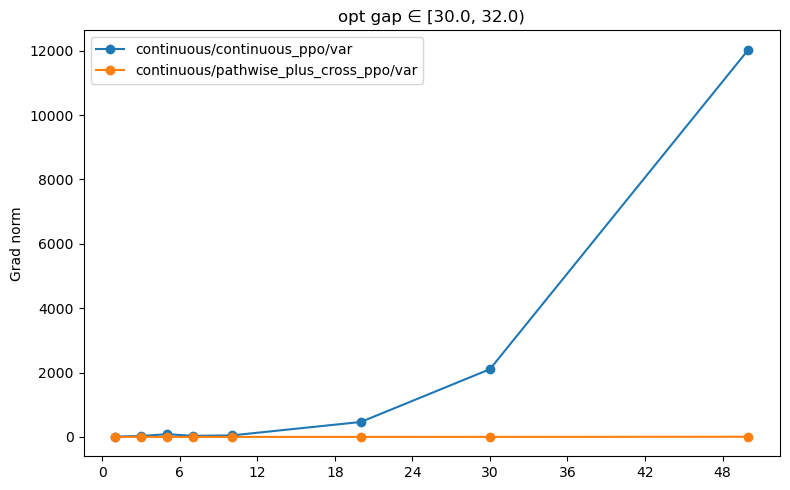

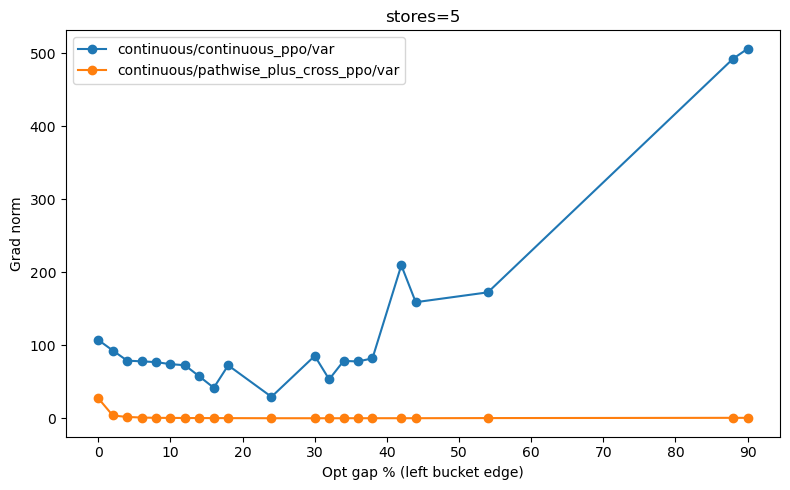

In [23]:
if __name__ == "__main__":

    BUCKET   = 30.0
    vm_index = 4
    stores = 5
    
    vm0 = [
        f"train/alignment_{d}/continuous/continuous_ppo",
        f"train/alignment_{d}/continuous/cross_ppo",
        f"train/alignment_{d}/discrete/cross_ppo",
        f"train/alignment_{d}/continuous/pathwise_plus_cross_ppo",
    ]

    vm1 = [
        f"train/grad_norm/continuous/continuous_ppo/true",
        f"train/grad_norm/discrete/cross_ppo/true",
        f"train/grad_norm/continuous/cross_ppo/true",
        f"train/grad_norm/continuous/pathwise/true",
    ]
    
    vm2 = [
        # f"train/grad_norm/continuous/continuous_ppo/var",
        f"train/grad_norm/discrete/cross_ppo/var",
        f"train/grad_norm/continuous/cross_ppo/var",
        f"train/grad_norm/continuous/pathwise/var",
    ]

    vm3 = [
        f"train/cosine/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/cosine/continuous/pathwise_plus_cross_ppo/mean",
    ]

    vm4 = [
        f"train/grad_norm/continuous/continuous_ppo/var",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/var",
        # f"train/grad_norm/continuous/cross_ppo/true",
        # f"train/grad_norm/continuous/pathwise/true",
        # f"train/grad_norm/discrete/cross_ppo/true",
        # "grad_ratio/pathwise_vs_cross",
    ]

    vm5 = [
        "grad_norm/continuous/continuous_ppo/snr",
        # "grad_norm/continuous/continuous_ppo/snr",
        # "grad_norm/continuous/cross_ppo/snr",
        # "grad_norm/continuous/pathwise/snr",
        # "grad_norm/discrete/cross_ppo/snr",
    ]

    ylabels = ["Alignment", "Grad norm (mean)", "Grad norm (var)", "Cosine sim", "Grad norm", "Signal to noise ratio"]

    vms = [vm0, vm1, vm2, vm3, vm4, vm5]
    vm = vms[vm_index]
    ylabel = ylabels[vm_index]

# Plot alignment metrics
    plot_metric_vs_x(
        df=bucketed_df,
        x_key="stores",
        filter_key="bucket_left",
        filter_value=BUCKET,
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
    )

    plot_metric_vs_x(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Opt gap % (left bucket edge)",
        filter_key="stores",
        filter_value=stores,
            value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
    )